# 5. Análisis de Correlación

Este notebook tiene como objetivo cumplir con el **Punto 5** de la práctica, investigando si existen relaciones estadísticas entre distintas variables del negocio.

Los análisis a realizar son:
* **5.a:** Relación entre el total de la venta y la edad del cliente.
* **5.b:** Correlación entre el género del cliente y el método de pago preferido.
* **5.c:** Correlación entre el uso de boletín y el uso de vale.

In [26]:
import sys
from pathlib import Path

RAIZ_PRACTICA = Path.cwd().resolve()
if not (RAIZ_PRACTICA / 'app').is_dir():
    RAIZ_PRACTICA = RAIZ_PRACTICA.parent

if str(RAIZ_PRACTICA) not in sys.path:
    sys.path.insert(0, str(RAIZ_PRACTICA))

print(f'Entorno listo: {RAIZ_PRACTICA}')

Entorno listo: C:\Users\50236\Documents\IA\SOG2-2S26_grupo8\Practica_1


In [27]:
from app.analisis.punto_02 import crear_motor, obtener_datos
from app.analisis.punto_05 import correlacion_venta_edad, correlacion_genero_metodo_pago, correlacion_boletin_vale
from IPython.display import display

motor = crear_motor(RAIZ_PRACTICA / '.env')
clientes, compras, control = obtener_datos(motor)

directorio_resultados = RAIZ_PRACTICA / '05-Analisis-correlacion' / 'resultados'

print("Datos descargados con éxito desde PostgreSQL.")
print(f"Clientes: {len(clientes):,} | Compras: {len(compras):,}")

Datos descargados con éxito desde PostgreSQL.
Clientes: 6,500 | Compras: 6,500


## 5.a Correlación entre Venta Total y Edad

Investigamos si existe una relación estadística entre la edad del cliente y el monto total que ha comprado, usando el coeficiente de Pearson (relación lineal) y Spearman (relación monótona, no necesariamente lineal).

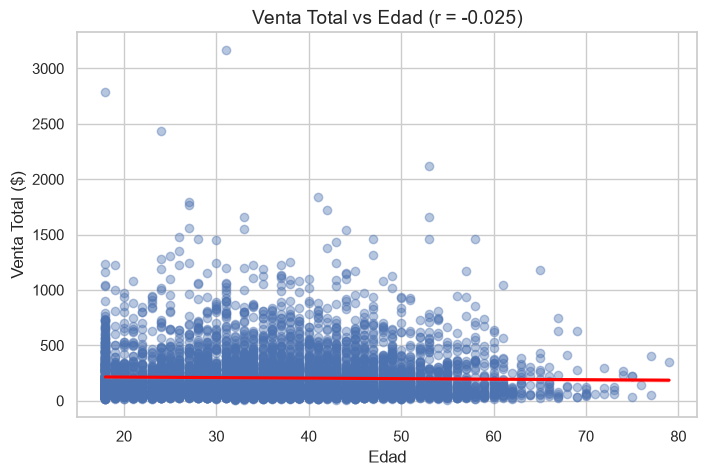

Pearson r = -0.0252 (p = 0.0419)
Spearman r = -0.0298 (p = 0.0162)
Interpretación: Nula o insignificante


In [28]:
res_edad = correlacion_venta_edad(clientes, directorio_resultados)

print(f"Pearson r = {res_edad['pearson_r']:.4f} (p = {res_edad['pearson_p_valor']:.4f})")
print(f"Spearman r = {res_edad['spearman_r']:.4f} (p = {res_edad['spearman_p_valor']:.4f})")
print(f"Interpretación: {res_edad['interpretacion']}")

## 5.b Correlación entre Género y Método de Pago Preferido

Como ambas variables son categóricas, usamos una tabla de contingencia junto con la prueba de chi-cuadrado y el coeficiente V de Cramér para medir la fuerza de la asociación.

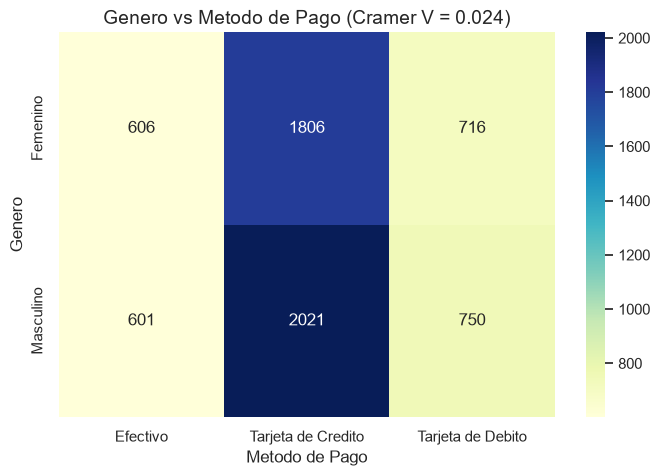

metodo_desc,Efectivo,Tarjeta de Credito,Tarjeta de Debito
genero_desc,,,
Femenino,606,1806,716
Masculino,601,2021,750


Chi2 = 3.7338 (p = 0.1546)
V de Cramér = 0.0240
Interpretación: Nula o insignificante


In [29]:
res_pago = correlacion_genero_metodo_pago(clientes, compras, directorio_resultados)

display(res_pago['tabla_contingencia'])
print(f"Chi2 = {res_pago['chi2']:.4f} (p = {res_pago['p_valor']:.4f})")
print(f"V de Cramér = {res_pago['cramers_v']:.4f}")
print(f"Interpretación: {res_pago['interpretacion']}")

## 5.c Correlación entre Boletín y Vale

Ambas variables son binarias (Sí/No), por lo que usamos el coeficiente Phi, matemáticamente equivalente a Pearson aplicado sobre valores 0/1, junto con la prueba de chi-cuadrado.

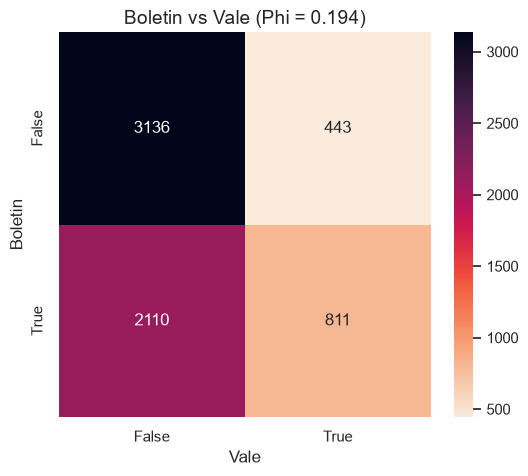

vale,False,True
boletin,,
False,3136,443
True,2110,811


Chi2 = 243.5653 (p = 6.5666e-55)
Phi = 0.1940
Interpretación: Debil


In [30]:
res_bv = correlacion_boletin_vale(compras, directorio_resultados)

display(res_bv['tabla_contingencia'])
print(f"Chi2 = {res_bv['chi2']:.4f} (p = {res_bv['p_valor']:.4e})")
print(f"Phi = {res_bv['phi']:.4f}")
print(f"Interpretación: {res_bv['interpretacion']}")


## Nota de interpretación

Con 6,500 registros, incluso relaciones estadísticamente significativas (p < 0.05) pueden ser prácticamente irrelevantes si el coeficiente es cercano a cero, como ocurre en 5.a y 5.b. En 5.c, aunque la asociación entre boletín y vale es "débil" según los umbrales estándar (Phi = 0.194), es la más fuerte de las tres relaciones estudiadas y sugiere que los clientes suscritos al boletín tienden más a usar vales de descuento.